# Clasifikasi Jeruk
End to End mechine learning dari awal sampai akhir
### library 
- `pandas` : untuk analisis data 
- `matplotlib` : virsualisasi Data 
- `sckit-learn` : (Otaknya) untuk keperluan mechine learning selama pengembangan  
- `joblib` : salah 1 libraray untuk menyimpan model yang sudah di hasilkan oleh scit-learn
- `streamlit` : untuk mendeploy dalam bentuk WEB

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression # # linear model logistik regrestion ( otaknya yg klasifikasi jeruk )
from sklearn.model_selection import train_test_split # membagi data menjadi data latih dan data uji
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix # untuk evaluasi model klasifikasi
# StandardScaler : untuk melakukan perubahan pada data numerik agar memiliki skala atau rentang nilai yang sama
# OneHotEncoder : untuk mengubah data kategorikal menjadi representasi numerik ( untuk 'asal_daerah','musim_panen')
# OrdinalEncoder : untuk mengubah data kategorikal menjadi representasi numerik yang dapat digunakan ( untuk 'warna')
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder 
# accuracy_score : utnuk menampilkan si model berapa
# classification_report : untuk melihat nilai raport nya secara kesuruhan
# confusion_matrix :  untuk melihat si model benar atau salah 
from sklearn.compose import ColumnTransformer # untuk menggabungkan ke 3 tahapan preprocessing jadi 1 ruangan
from sklearn.pipeline import Pipeline # dan di salurkan ke pipline sehingga mem-press semuanya menjadi 1 model secara utuh


### Management data ||  explorasi data 


In [3]:
# ini dataset yang emang bagus atau mainan aja , jadi bisa jadi akurasi sampai 99%
df = pd.read_csv("jeruk-balence-500.csv")

print("\n [!] datanya ")
print(df)
print("\n [!] colom dan baris datanya ")
print(df.shape)

print("\n [!] structure dataset ")
df.info() # tampil tipe datanya , Object ( ini di kelola dan di ubah ke angka )

print("\n [!] tampilkan informasi statistik Descriptif")
df.describe() # untuk amannya natik di lakukan proses scaling , agar angka di press ke 1 angka yang sama

print("\n [!]  tampilkna jenis jenis colomnya  ( colom di file nya)")
print("asal daerah :")
df["asal_daerah"]
print("warna :")
df["warna"]
print("musim panen")
df["musim_panen"]
print("kualitas :")
df["kualitas"]

print("\n [!] 5 data teratas :")
df.head()
print("\n [!] 5 data terbawah :")
df.tail()


 [!] datanya 
     diameter  berat  tebal_kulit  kadar_gula  asal_daerah   warna  \
0        7.75  216.4         0.51        11.1   Kalimantan  oranye   
1        7.43  237.9         0.43        10.6  Jawa Tengah  kuning   
2        7.82  195.1         0.60        12.9   Jawa Barat  oranye   
3        8.26  184.9         0.49        13.9   Kalimantan  oranye   
4        7.38  182.2         0.42        10.6   Jawa Barat  oranye   
..        ...    ...          ...         ...          ...     ...   
495      6.06  106.0         0.73         7.7  Jawa Tengah   hijau   
496      5.50  108.8         0.92        10.4   Jawa Barat   hijau   
497      5.50   95.5         1.05         8.4   Jawa Barat   hijau   
498      7.69  221.8         0.70        13.0   Jawa Barat  oranye   
499      7.57  200.5         0.46        13.6   Kalimantan  oranye   

    musim_panen kualitas  
0       kemarau    Bagus  
1       kemarau    Bagus  
2         hujan    Bagus  
3         hujan    Bagus  
4       k

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
495,6.06,106.0,0.73,7.7,Jawa Tengah,hijau,kemarau,Jelek
496,5.50,108.8,0.92,10.4,Jawa Barat,hijau,kemarau,Jelek
497,5.50,95.5,1.05,8.4,Jawa Barat,hijau,hujan,Jelek
498,7.69,221.8,0.70,13.0,Jawa Barat,oranye,hujan,Bagus
499,7.57,200.5,0.46,13.6,Kalimantan,oranye,hujan,Bagus


visualisasi Data  : 
tampilkan dan visualisasi data  : 


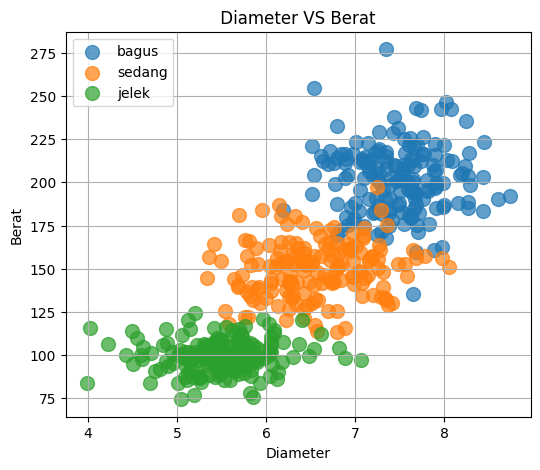

In [4]:
print("visualisasi Data  : ") 
bagus  = df[df["kualitas"] == "Bagus"]
sedang = df[df["kualitas"] == "Sedang"]
jelek = df[df["kualitas"] == "Jelek"]

print("tampilkan dan visualisasi data  : ")
plt.figure(figsize=(6,5))  # buat semacam bingkai gambar (lebar 600 and tinggi 500)
plt.scatter(bagus["diameter"],bagus["berat"],s=100,alpha=0.7 , label="bagus"  )# buat visualisasi data berdasarkan diameter dan berat jeruk
plt.scatter(sedang["diameter"],sedang["berat"],s=100,alpha=0.7 , label="sedang" )# buat visualisasi data berdasarkan diameter dan berat jeruk
plt.scatter(jelek["diameter"],jelek["berat"],s=100,alpha=0.7  ,label="jelek" )# buat visualisasi data berdasarkan diameter dan berat jeruk
# judul sumbu x dan y 
plt.xlabel("Diameter")
plt.ylabel("Berat")
plt.title(" Diameter VS Berat ")
plt.legend() # tampil info berdasarkan Label (belum ada)
plt.grid(True) # garis garis 

Visualisasi Untuk Kadar Gula dan Kulit

visualisasi Data  : 
tampilkan dan visualisasi data  : 


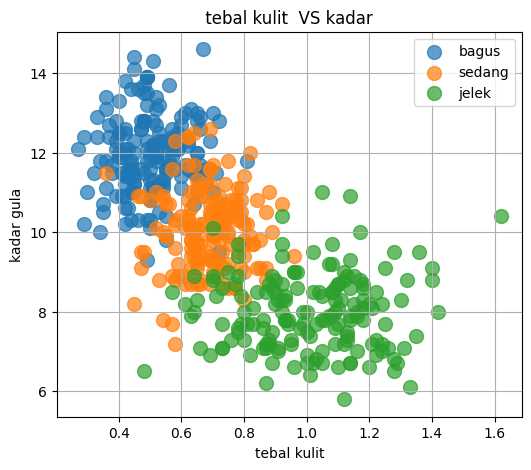

In [5]:
print("visualisasi Data  : ") 
bagus  = df[df["kualitas"] == "Bagus"]
sedang = df[df["kualitas"] == "Sedang"]
jelek = df[df["kualitas"] == "Jelek"]

print("tampilkan dan visualisasi data  : ")
plt.figure(figsize=(6,5))  # buat semacam bingkai gambar (lebar 600 and tinggi 500)
plt.scatter(bagus["tebal_kulit"],bagus["kadar_gula"],s=100,alpha=0.7  , label="bagus"  )# buat visualisasi data berdasarkan tebal kulit dan"kadar gula"jeruk
plt.scatter(sedang["tebal_kulit"],sedang["kadar_gula"],s=100,alpha=0.7 , label="sedang"  )# buat visualisasi data berdasarkan tebal kulit dan"kadar gula"jeruk
plt.scatter(jelek["tebal_kulit"],jelek["kadar_gula"],s=100,alpha=0.7  , label="jelek"  )# buat visualisasi data berdasarkan tebal kulit dan"kadar gula"jeruk
# judul sumbu x dan y 
plt.xlabel("tebal kulit")
plt.ylabel("kadar gula")
plt.title(" tebal kulit  VS kadar ")
plt.legend() # tampil info berdasarkan Label (belum ada)
plt.grid(True) # garis garis 

**ouput** : Ternyata dari kadar gula jeruk yang memiliki kualitas bagus adalah yang tebal kulitnya tipis tapi kadar gula nya tinggi

## membuat Model nya

In [6]:
X = df[["diameter","berat"	,"tebal_kulit","kadar_gula"	,"asal_daerah"	,"warna","musim_panen"]] # 7 kolom fiture yang akan di gunakan 
y =df["kualitas"]   # 1 kolom target

# membagi data untuk llatihan dan untuk testting
# 20% untuk testing dan 80% untuk training ,
# random_state : mengacak angka agar ada urutan dengan pola tertentu 
X_train , X_test , y_train ,y_test = train_test_split(
    X,y ,test_size=0.2 , random_state=42   
)

# pegelolahan pada preprosesing
# persiapan berdasarkan preprocesing yang memproses nya 
numeric_columns = ["diameter","berat","tebal_kulit","kadar_gula"]
catagorical_columns = ["asal_daerah","musim_panen"] 
ordinal_columns = ["warna"]

warna_order = ["hijau","kuning","oranye"] # urutan warna
ordinal_order =[warna_order] # ordinal order-nya 

preprocessing =ColumnTransformer(
    transformers=[
        ("scaler",StandardScaler(),numeric_columns),
        ("ohe",OneHotEncoder(),catagorical_columns),
        ("oe",OrdinalEncoder(categories=ordinal_order),ordinal_columns)
    ]
)


model = Pipeline( 
                 steps=[
                     ("preprocessing",preprocessing),
                     ("model" ,LogisticRegression())
                 ])

model # tampilkan

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('ohe', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Cara membagi tetsing ini ibaratkan misal ada 10 soal 
- 2 soal sebagai soal ulangan 
- 8 soal untuk latiahan , 
jadi mereka akan belajar dari 80% soal yang ada baru menjumpai 20% soal test nya


In [9]:
# model suruh belajar 
# fit : suruh si otak belajar mengerjakan soal latihan dengan di pandu dengan jawab latihan
model.fit(X_train, y_train)

# X_train : soal latihan 
# X_test : soal ulangan  
# y_train : kunci jawaban latihan 
# y_test :  kunci jawaban ulangan
# ulangan dengan soal test yang di berikan 
y_predisksi = model.predict(X_test)

print(f"akurasi skor : {accuracy_score(y_test , y_predisksi)}")
print("\n Clasifikasi report :\n" , classification_report(y_test ,y_predisksi)) # informatio yang lebih details
print("\n Confusion Matrix :\n",confusion_matrix(y_test,y_predisksi)) # tampilakan jawabanya , dan salahnya apa


akurasi skor : 0.99

 Clasifikasi report :
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100


 Confusion Matrix :
 [[35  0  0]
 [ 0 40  1]
 [ 0  0 24]]


### Training dengan data baru 
> contoh data baru untuk tarining model nya

In [12]:
# contoh buat data frame secara manual 
new_data = pd.DataFrame([[3.54,54.4,0.52,10.8,"Kalimantan","kuning","hujan"]],
                        columns=["diameter","berat","tebal_kulit","kadar_gula","asal_daerah","warna","musim_panen"])

# Prediksi kelas
predik = model.predict(new_data)[0]

# Probabilitas untuk semua kelas
presentase = model.predict_proba(new_data)[0]

# Ambil index kelas yang diprediksi
index_pred = list(model.classes_).index(predik)

# Probabilitas kelas prediksi
confidence = presentase[index_pred] * 100

print(f"Model memprediksi {predik} dengan tingkat keyakinan {confidence:.2f}%")


Model memprediksi Jelek dengan tingkat keyakinan 99.24%


## Import Model agar bisa di gunakan 
- misal di web  

In [13]:
import joblib 

# hasilkan hasil model nya ke file model-klasifikasi-jeruk.joblib
joblib.dump(model , "model-klasifikasi-jeruk.joblib")

['model-klasifikasi-jeruk.joblib']